In [1]:
import numpy as np
import finufft
import matplotlib.pyplot as pl
import time
pi = np.pi

In [2]:
c = 3e8
G = 6.67e-11
const = 96/5*pi**(8/3)*(G/c**3)**(5/3)

f_max = 200
f_nufft = 3*f_max

In [5]:
def t_max_calc(f0, beta, f_max):
    temp0 = 0.375/beta
    temp1 = 1-(f0/f_max)**(8/3)
    return temp0*temp1

def nufft(beta, data, t, bin_no):
    bins = np.arange(bin_no) - bin_no//2
    
    tau = -3/5*(1-8/3*beta*t)**(5/8)/beta
    scale = (2*pi)/(tau[-1]-tau[0])
    tau *= scale
    start_diff = -pi-tau[0]
    tau += start_diff
    nufft_amp = finufft.nufft1d1(tau, data, bin_no)
    nufft_freq = -bins*scale/(2*pi)
    nufft_power = np.abs(nufft_amp/len(data))**2
    
    sort_idx = np.argsort(nufft_power)
    thresh_idx = np.searchsorted(nufft_power, np.array([0.1]), sorter=sort_idx)[0]
    return nufft_power[sort_idx[-1]]

def main_calc(f, M):
    """
    Calculates the power loss curve as a function of \delta \beta / \beta steps
    """
    beta = const*f**(8/3)*M**(5/3)
    T_obs = min(5e4, t_max_calc(f, beta, 200))
    
    t_nufft = np.arange(0, T_obs, 1/f_nufft)
    phi = -6*pi/5*f*(1-8./3.*(beta)*t_nufft)**(5/8)/beta
    phi = np.mod(phi,2*pi)
    signal_nufft = 1*np.exp(1j*phi)
#    signal_nufft[:int(1e3)] = np.zeros((int(1e3)))
#    signal_nufft[-int(1e3):] = np.zeros((int(1e3)))
    
    ref_power = nufft(beta, signal_nufft, t_nufft, len(signal_nufft))
    result = np.array([nufft((1+i)*beta, signal_nufft, t_nufft, len(signal_nufft)) for i in offset_arr])  
#    mempool.free_all_blocks()
    
    return result/ref_power

In [11]:
f0 = 20
mass_space = np.logspace(-1, -2.5, 5) * 2e30
beta_space = const*f0**(8/3)*mass_space**(5/3)
offset_arr = np.logspace(-6, -3, 10)

0.8810911933581035


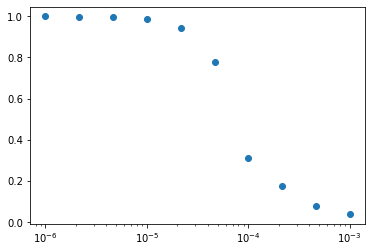

In [20]:
tic = time.time()
test = main_calc(20, 1e-2*2e30)
toc = time.time()
pl.semilogx(offset_arr, test, 'o')

print((toc-tic)/60)

In [43]:
f = 20
M = 1e-2*2e30
beta = const*f**(8/3)*M**(5/3)
T_obs = min(5e4, t_max_calc(f, beta, 200))

t_nufft = np.arange(0, T_obs, 1/f_nufft)
phi = -6*pi/5*f*(1-8./3.*(beta)*t_nufft)**(5/8)/beta
phi = np.mod(phi,2*pi)
signal_nufft = 1*np.exp(1j*phi)
ref_power = nufft(beta, signal_nufft, t_nufft, len(signal_nufft))

In [51]:
def optimized_func(log_percent_offset):
    percent_offset = 10**log_percent_offset
    subopt_power = nufft((1+percent_offset)*beta, signal_nufft, t_nufft, len(signal_nufft))
    return subopt_power/ref_power - 0.9

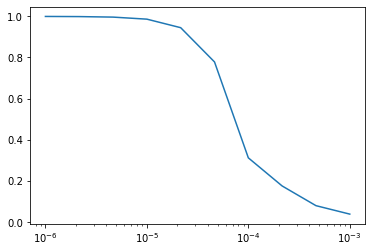

In [32]:
test = [optimized_func(i) for i in offset_arr]
pl.semilogx(offset_arr, test, 'o')

In [57]:
guess

2.1544346900318823e-05

In [38]:
from scipy import optimize

In [54]:
found = optimize.root_scalar(optimized_func, x0=-5, bracket=(-6, -3))

In [56]:
10**found.root

2.9780758684163704e-05

In [58]:
found

      converged: True
           flag: 'converged'
 function_calls: 26
     iterations: 25
           root: -4.526064242509002